# 03 — The `pivot_cci` **best version** baseline: know your starting point

Before decomposing, we pin down the **best harness version, whole strategy with all filters**, as our baseline: what it earns, its equity shape, drawdowns, and — across the universe — *which assets* it makes/loses money on.

**Best version = the current `strategy.py`** (the iter-11 champion: `cci_exit=40`, BTC/ETH, composite **1.22**, OOS Sharpe **2.54**). We import that exact code via `strat_signals()` — same CCI/RSI/pivot/EMA200/funding logic, same `.shift(1)`. We do NOT reimplement it.

**Period = the champion's full evaluation window `2024-01 → 2026-01`** (what the harness judged), not just 2024. 2024 alone is the weak in-sample stretch (train Sharpe −1.29); the edge lives in 2025–26.

**Is this OOS-peeking?** No. We are *characterizing a frozen artifact* over the window the harness already scored — not fitting to it. The 2025 seal in this line applies to the **event-study notebooks where we hunt for *new* signal** (nb02, nb04+); it does not forbid describing the equity of an already-decided champion.

**What the sim is / isn't.** `backtest()` = honest full-period single-instrument sim: PnL = held-position × bar-return, minus 0.075%/side (0.15% round-trip). **Not** the harness — no walk-forward stitching, no DSR, no activity penalty, no funding-PnL credit. So the raw Sharpe here is *lower* than the composite (it includes weak 2024 and dilutes by ~92% flat time). The point is the **shape**, not to reproduce 1.22.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

TF = "1h"
START, END = "2024-01-01", "2026-01-01"   # champion's full harness window
print("pivot_cci params:", PCCI_PARAMS)

pivot_cci params: {'cci_period': 14, 'cci_threshold': 80, 'rsi_period': 14, 'rsi_threshold': 40, 'funding_threshold': 0.0005, 'pivot_level': 1, 'trend_period': 200, 'cci_exit': 40, 'long_only': 0}


## Part A — the strategy's real config: BTC + ETH, full window (2024→2026)

The champion trades only **BTCUSDT / ETHUSDT**. We run each, then an equal-weight (50/50, rebalanced each bar) combined portfolio, over the full 2024-01 → 2026-01 window.

In [2]:
MAJORS = ["BTCUSDT", "ETHUSDT"]
res, nets = {}, {}
for s in MAJORS:
    df = ohlcv(s, START, END, TF)
    r = backtest(strat_signals(df, s), df["close"])
    res[s] = r; nets[s] = r["net"]

# equal-weight combined portfolio (50/50 each bar)
net_df = pd.DataFrame(nets).fillna(0.0)
port_net = net_df.mean(axis=1)
port_eq = (1 + port_net).cumprod()
port_dd = port_eq / port_eq.cummax() - 1

def summarize(r):
    return {k: round(r[k], 4) for k in ["total_return", "sharpe", "max_dd", "n_trades",
            "win_rate", "avg_pnl", "profit_factor", "avg_hold", "time_in_pos", "n_long", "n_short"]}

tblA = pd.DataFrame({s: summarize(res[s]) for s in MAJORS})
tblA["COMBINED"] = {
    "total_return": round(port_eq.iloc[-1] - 1, 4),
    "sharpe": round(port_net.mean() / port_net.std() * np.sqrt(BARS_PER_YEAR_1H), 4),
    "max_dd": round(port_dd.min(), 4),
    "n_trades": res["BTCUSDT"]["n_trades"] + res["ETHUSDT"]["n_trades"],
    "win_rate": np.nan, "avg_pnl": np.nan, "profit_factor": np.nan, "avg_hold": np.nan,
    "time_in_pos": round((port_net != 0).mean(), 4), "n_long": np.nan, "n_short": np.nan,
}
tblA.T

,total_return,sharpe,max_dd,n_trades,win_rate,avg_pnl,profit_factor,avg_hold,time_in_pos,n_long,n_short
BTCUSDT,0.0162,0.1353,-0.1242,96.0,0.6979,0.0010,1.3605,6.9167,0.0378,49.0,47.0
ETHUSDT,0.1561,0.6728,-0.0622,98.0,0.6531,0.0023,1.7031,7.3776,0.0412,47.0,51.0
COMBINED,0.0886,0.5675,-0.0726,194.0,NaN,NaN,NaN,NaN,0.0777,NaN,NaN


[saved] notebooks\pivots\_out\03_equity_majors.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/03_equity_majors.png')

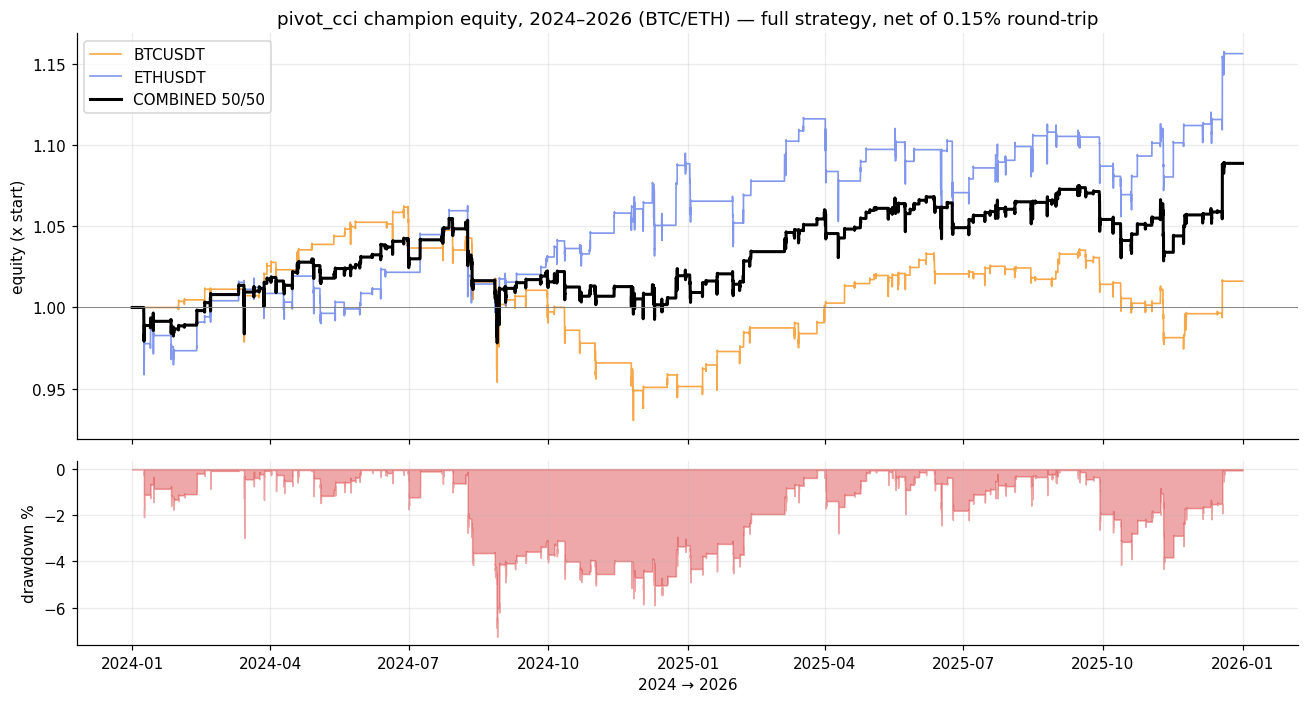

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [2.2, 1]})
for s, c in [("BTCUSDT", "#f7931a"), ("ETHUSDT", "#627eea")]:
    ax1.plot(res[s]["equity"].index, res[s]["equity"], lw=1.1, color=c, alpha=0.8, label=s)
ax1.plot(port_eq.index, port_eq, lw=2.0, color="black", label="COMBINED 50/50")
ax1.axhline(1.0, color="gray", lw=0.6)
ax1.set_ylabel("equity (x start)"); ax1.legend()
ax1.set_title("pivot_cci champion equity, 2024–2026 (BTC/ETH) — full strategy, net of 0.15% round-trip")
ax2.fill_between(port_dd.index, port_dd * 100, 0, color="#d62728", alpha=0.4)
ax2.set_ylabel("drawdown %"); ax2.set_xlabel("2024 → 2026")
show("03_equity_majors")

In [4]:
# monthly returns of the combined portfolio
monthly = (1 + port_net).resample("MS").prod() - 1
mtab = pd.DataFrame({"month": monthly.index.strftime("%Y-%m"), "return_%": (monthly.values * 100).round(2)})
print("green months:", int((monthly > 0).sum()), "/", len(monthly),
      "| best", round(monthly.max()*100,2), "% | worst", round(monthly.min()*100,2), "%")
mtab.set_index("month").T

green months: 15 / 24 | best 3.0 % | worst -3.54 %


month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
return_%,-1.13,1.95,0.94,0.82,0.51,0.05,1.63,-3.54,0.44,-0.61,...,2.45,-0.01,0.38,-1.37,1.08,0.6,-1.19,-0.34,0.6,3.0


## Part B — the whole universe, broken down by asset

Now run the same champion strategy on **every symbol with full 2024→2025 coverage** (each traded standalone, same params), over the same 2024-01 → 2026-01 window, and rank per-asset performance. This tells us whether the edge is BTC/ETH-specific or spread across the market — and where it bleeds. Cached to `_out/` so re-runs are instant.

In [5]:
from pathlib import Path
CACHE = Path("_out/03_universe_full.parquet")

def covers_full(sym):
    lo, hi, n = coverage(sym)
    return lo <= "2024-01" and hi >= "2025-12"

if CACHE.exists():
    uni = pd.read_parquet(CACHE)
    print("loaded cache:", len(uni), "symbols")
else:
    UNIV = [s for s in list_symbols() if covers_full(s)]
    rows = []
    for s in UNIV:
        try:
            df = ohlcv(s, START, END, TF)
        except Exception:
            continue
        if len(df) < 500:
            continue
        r = backtest(strat_signals(df, s), df["close"])
        bh = float(df["close"].iloc[-1] / df["close"].iloc[0] - 1)          # buy&hold
        vol = float(df["close"].pct_change().std() * np.sqrt(BARS_PER_YEAR_1H))  # annualized vol
        rows.append({"symbol": s, "total_return": r["total_return"], "sharpe": r["sharpe"],
                     "max_dd": r["max_dd"], "n_trades": r["n_trades"], "win_rate": r["win_rate"],
                     "avg_pnl": r["avg_pnl"], "profit_factor": min(r["profit_factor"], 10),
                     "time_in_pos": r["time_in_pos"], "n_long": r["n_long"], "n_short": r["n_short"],
                     "buyhold": bh, "ann_vol": vol})
    uni = pd.DataFrame(rows)
    uni.to_parquet(CACHE)
    print("computed + cached:", len(uni), "symbols")

print(f"profitable: {(uni.total_return > 0).mean()*100:.0f}% of {len(uni)} symbols")
print(f"median total_return {uni.total_return.median()*100:+.2f}%  | mean {uni.total_return.mean()*100:+.2f}%")
print(f"median n_trades {uni.n_trades.median():.0f}  | median win_rate {uni.win_rate.median():.2f}")
uni.describe().round(3).T[["mean", "50%", "std", "min", "max"]]

computed + cached: 148 symbols
profitable: 38% of 148 symbols
median total_return -9.49%  | mean -8.21%
median n_trades 94  | median win_rate 0.65


,mean,50%,std,min,max
total_return,-0.082,-0.095,0.237,-0.630,0.494
sharpe,-0.167,-0.159,0.683,-3.562,1.662
max_dd,-0.302,-0.291,0.140,-0.701,-0.020
n_trades,92.743,94.000,12.279,14.000,116.000
win_rate,0.636,0.647,0.069,0.000,0.747
avg_pnl,-0.000,-0.000,0.003,-0.008,0.006
profit_factor,1.064,0.996,0.361,0.000,2.701
time_in_pos,0.042,0.043,0.007,0.006,0.056
n_long,34.628,34.500,7.450,9.000,61.000
n_short,58.115,59.000,10.352,5.000,79.000


[saved] notebooks\pivots\_out\03_universe_dist.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/03_universe_dist.png')

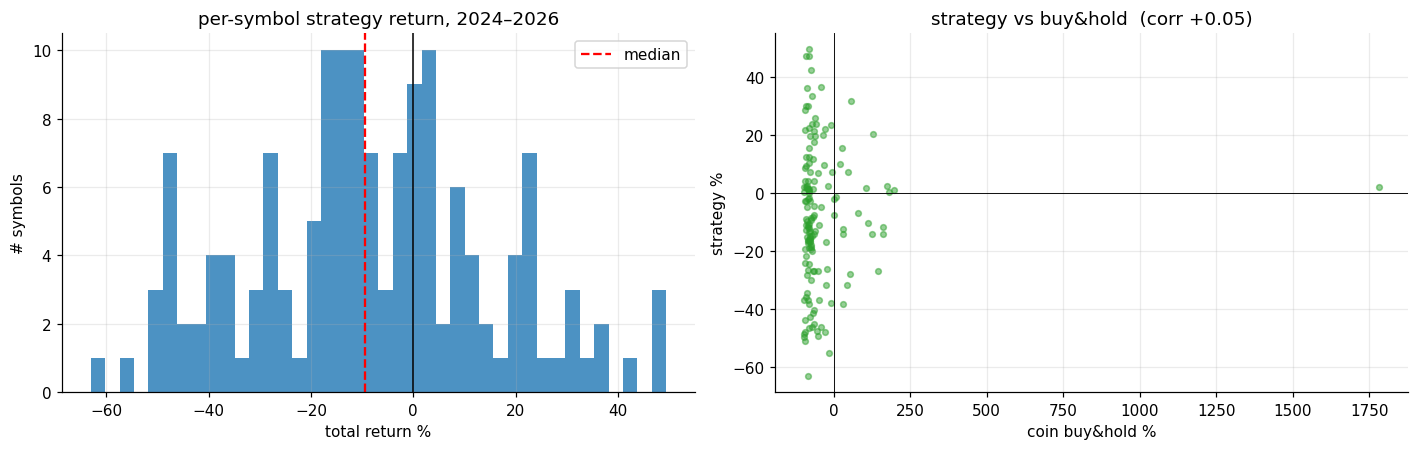

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
ax1.hist(uni.total_return * 100, bins=40, color="#1f77b4", alpha=0.8)
ax1.axvline(0, color="k", lw=1); ax1.axvline(uni.total_return.median()*100, color="red", ls="--", label="median")
ax1.set_title("per-symbol strategy return, 2024–2026"); ax1.set_xlabel("total return %"); ax1.set_ylabel("# symbols"); ax1.legend()
# does the strategy just track how the coin itself did?
ax2.scatter(uni.buyhold * 100, uni.total_return * 100, s=14, alpha=0.5, color="#2ca02c")
ax2.axhline(0, color="k", lw=0.6); ax2.axvline(0, color="k", lw=0.6)
cor = uni.buyhold.corr(uni.total_return)
ax2.set_title(f"strategy vs buy&hold  (corr {cor:+.2f})"); ax2.set_xlabel("coin buy&hold %"); ax2.set_ylabel("strategy %")
show("03_universe_dist")

In [7]:
cols = ["symbol", "total_return", "sharpe", "max_dd", "n_trades", "win_rate", "profit_factor", "buyhold", "ann_vol"]
print("===== TOP 15 GAINERS =====")
top = uni.sort_values("total_return", ascending=False).head(15)[cols].copy()
print("===== BOTTOM 15 (LOSERS) =====")
bot = uni.sort_values("total_return").head(15)[cols].copy()
disp = pd.concat([top.assign(grp="TOP"), bot.assign(grp="BOTTOM")])
for c in ["total_return", "max_dd", "win_rate", "buyhold", "ann_vol"]:
    disp[c] = (disp[c] * 100).round(1)
disp[["grp"] + cols].set_index(["grp", "symbol"])

===== TOP 15 GAINERS =====
===== BOTTOM 15 (LOSERS) =====


total_return    sharpe  max_dd  n_trades  win_rate  \
grp    symbol                                                            
TOP    ZILUSDT              49.4  1.662217    -8.3        89      74.2   
       HNTUSDT              47.3  0.911802   -18.6        90      73.3   
       IMXUSDT              47.0  1.066083   -15.0       107      68.2   
       IOTAUSDT             42.2  1.009072   -22.2        98      70.4   
       CRVUSDT              36.4  0.885140   -13.8        98      66.3   
       WLDUSDT              36.1  0.753591   -19.4        96      66.7   
       COTIUSDT             33.3  0.859996   -22.9        91      74.7   
       PENDLEUSDT           31.8  0.657203   -27.2       103      69.9   
       KAVAUSDT             30.1  0.976173   -16.0        82      67.1   
       GRTUSDT              30.1  0.817627   -15.8        97      64.9   
       ASTRUSDT             28.4  0.830845   -16.0       110      72.7   
       NEARUSDT             25.9  0.705237   -16.3       107      67.3   
       COMPUSDT             23.8  0.760130   -17.1        93      68.8   
       VETUSDT              23.7  0.824876   -13.4        92      69.6   
       CROUSDT              23.4  0.791188   -12.1        84      66.7   
BOTTOM AUCTIONUSDT         -63.0 -1.488535   -70.1        94      58.5   
       JASMYUSDT           -55.3 -1.264859   -60.6        92      54.3   
       AXLUSDT             -51.1 -1.286342   -56.2        90      64.4   
       TIAUSDT             -49.6 -1.373258   -61.4        90      56.7   
       CVXUSDT             -49.4 -1.066962   -57.6        98      63.3   
       ORDIUSDT            -48.5 -1.278717   -57.9       104      60.6   
       RPLUSDT             -48.1 -0.825902   -63.8       110      57.3   
       PEOPLEUSDT          -47.8 -1.046034   -64.9        79      64.6   
       NMRUSDT             -47.5 -0.868334   -55.6        82      57.3   
       COREUSDT            -46.5 -0.810121   -52.4        92      57.6   
       CKBUSDT             -46.2 -1.321643   -52.1        89      57.3   
       POLYXUSDT           -46.2 -0.985190   -56.6        97      64.9   
       ARUSDT              -45.2 -1.183947   -51.9        88      54.5   
       HFTUSDT             -43.9 -1.062072   -52.5       101      56.4   
       API3USDT            -42.6 -0.964304   -44.7        87      56.3   

                    profit_factor  buyhold  ann_vol  
grp    symbol                                        
TOP    ZILUSDT           2.700884    -81.4     93.6  
       HNTUSDT           1.711653    -80.7    125.2  
       IMXUSDT           1.781544    -89.9    110.4  
       IOTAUSDT          1.756788    -73.7    110.2  
       CRVUSDT           1.574422    -41.1    121.1  
       WLDUSDT           1.567819    -87.0    131.9  
       COTIUSDT          1.653061    -70.7    127.1  
       PENDLEUSDT        1.447966     56.9    126.2  
       KAVAUSDT          1.807043    -91.5     96.5  
       GRTUSDT           1.678966    -82.5    103.1  
       ASTRUSDT          1.609396    -92.9     95.7  
       NEARUSDT          1.470315    -59.9    109.7  
       COMPUSDT          1.666641    -57.3    100.5  
       VETUSDT           1.680456    -69.9    100.2  
       CROUSDT           1.963668     -8.7    104.5  
BOTTOM AUCTIONUSDT       0.558186    -82.3    127.7  
       JASMYUSDT         0.525066    -14.3    130.9  
       AXLUSDT           0.585136    -94.2    121.5  
       TIAUSDT           0.585860    -96.2    122.7  
       CVXUSDT           0.657663    -52.3    127.5  
       ORDIUSDT          0.640965    -94.9    125.0  
       RPLUSDT           0.700154    -93.7    119.4  
       PEOPLEUSDT        0.658691    -26.4    168.6  
       NMRUSDT           0.564309    -53.3    125.6  
       COREUSDT          0.605545    -80.5    126.7  
       CKBUSDT           0.575617    -39.7    129.3  
       POLYXUSDT         0.722093    -70.2    111.3  
       ARUSDT            0.636252    -64.4    128.2  
       HFTUSDT           0.6960

## Part C — clustering assets by strategy behaviour

Group the symbols by *how the strategy behaves on them* — features: strategy return, win-rate, trades, time-in-position, the coin's own volatility and drift. KMeans (k=4) on standardized features; then read what each cluster is.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feat_cols = ["total_return", "win_rate", "n_trades", "time_in_pos", "ann_vol", "buyhold"]
X = uni[feat_cols].fillna(0.0).to_numpy()
Xs = StandardScaler().fit_transform(X)
K = 4
uni["cluster"] = KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(Xs)

prof = uni.groupby("cluster").agg(
    n=("symbol", "size"),
    ret_pct=("total_return", lambda x: round(x.mean()*100, 2)),
    win=("win_rate", lambda x: round(x.mean(), 3)),
    trades=("n_trades", lambda x: round(x.mean(), 1)),
    tip=("time_in_pos", lambda x: round(x.mean(), 3)),
    ann_vol=("ann_vol", lambda x: round(x.mean(), 2)),
    buyhold_pct=("buyhold", lambda x: round(x.mean()*100, 1)),
    pct_profit=("total_return", lambda x: round((x > 0).mean()*100, 0)),
).sort_values("ret_pct", ascending=False)
examples = uni.groupby("cluster")["symbol"].apply(lambda s: ", ".join(s.head(6)))
prof["examples"] = examples
prof

,n,ret_pct,win,trades,tip,ann_vol,buyhold_pct,pct_profit,examples
cluster,,,,,,,,,
1,63,9.71,0.669,88.5,0.038,1.05,-29.6,70.0,"ARKUSDT, ASTRUSDT, BCHUSDT, BELUSDT, BIGTIMEUS..."
3,1,2.05,0.688,93.0,0.039,1.27,1782.6,100.0,ZECUSDT
2,1,-2.03,0.000,14.0,0.006,0.01,-0.0,0.0,USDCUSDT
0,83,-22.01,0.618,96.9,0.046,1.12,-61.4,13.0,"API3USDT, ARPAUSDT, ARUSDT, ATOMUSDT, AUCTIONU..."


[saved] notebooks\pivots\_out\03_clusters.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/03_clusters.png')

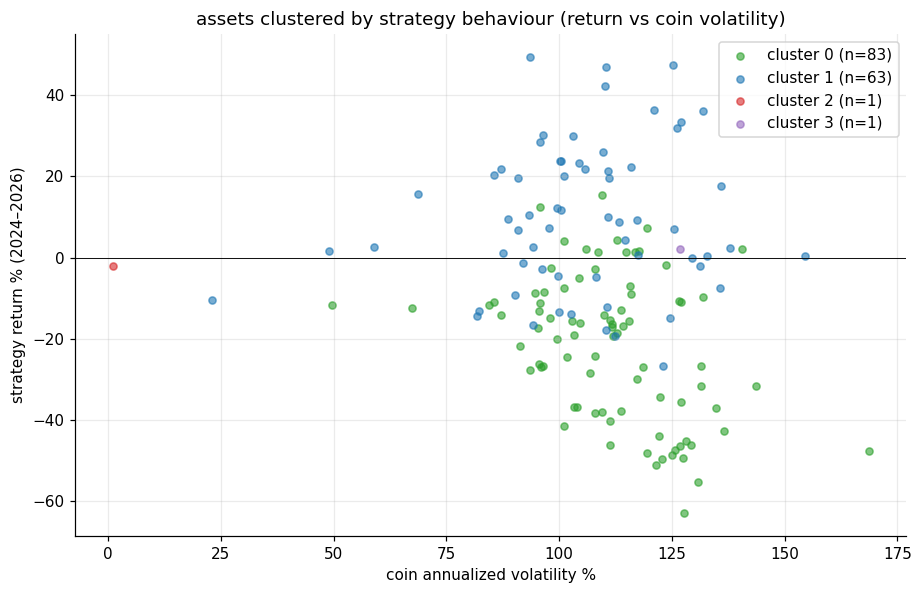

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
palette = ["#2ca02c", "#1f77b4", "#d62728", "#9467bd", "#ff7f0e"]
for cl in sorted(uni.cluster.unique()):
    d = uni[uni.cluster == cl]
    ax.scatter(d.ann_vol * 100, d.total_return * 100, s=22, alpha=0.6,
               color=palette[cl % len(palette)], label=f"cluster {cl} (n={len(d)})")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("coin annualized volatility %"); ax.set_ylabel("strategy return % (2024–2026)")
ax.set_title("assets clustered by strategy behaviour (return vs coin volatility)")
ax.legend()
show("03_clusters")

## Verdict — the champion works on BTC/ETH; the BTC/ETH restriction is *survival*, not arbitrary

**Part A — BTC/ETH (the real config), 2024→2026: modestly positive and reasonably smooth.** Combined **+8.9%**, Sharpe **0.57** (this simple sim; the harness composite 1.22 rides WF-stitching + funding credit + a different Sharpe def), maxDD **−7.3%**, 194 trades, **15/24 green months**, worst month −3.5%. BTC +1.6% (PF 1.36), ETH +15.6% (PF 1.70). Long/short roughly balanced (~48 each side). The equity climbs through H1-2024, takes its one real hit in the Aug-2024 selloff (−7% DD), then grinds up steadily through 2025. **This is a genuine, if modest, positive edge on the majors.**

**Part B — the whole universe (148 alts, standalone): it LOSES, hard.** Only **38% profitable**, **median −9.5%**, mean −8.2%. corr(strategy, buy&hold) collapses to **+0.05**. The reason is written in the buy&hold column: **alts were massacred over 2024–26** (median coin −75%). A long-biased dip-buyer in a bleeding market catches falling knives. And note **median 59 shorts vs 34 longs** per symbol — in the alt bear the EMA200 gate correctly flipped most signals to shorts, **yet it still lost**: shorting alt downtrends at R1 touches gets run over by bear-market bounces (exactly nb02's R1 = anti-signal, now confirmed over two years).

**Part C — clusters: the split is survivor-vs-corpse, not a volatility band.**

| cluster | n | strat ret | win | coin buy&hold | % profitable | what it is |
|---|---|---|---|---|---|---|
| **1** | 63 | **+9.7%** | 67% | −30% | **70%** | coins that fell only moderately — strategy still nets out ahead |
| **0** | 83 | **−22.0%** | 62% | −61% | **13%** | coins that got destroyed — strategy bleeds with them |
| 3 | 1 | +2.0% | 69% | +1783% | 100% | ZEC, the lone moonshot (MR badly under-captures it) |
| 2 | 1 | −2.0% | — | 0% | 0% | USDCUSDT stablecoin (ignore) |

Volatility (x-axis of the scatter) does **not** separate winners from losers — both clusters span ~90–130% annualized vol. The separator is the coin's **fate**: survive the bear (cluster 1) → the dip-buys work; bleed out (cluster 0) → the strategy bleeds too, with the classic **win-rate trap** (cluster-0 corpses still win ~62% of trades but blow up on fat-tail losses: AUCTION win 59% / return −63% / maxDD −70%).

### The one-sentence baseline
`pivot_cci` is a **long-biased daily-pivot mean-reversion whose per-asset PnL is dominated by the underlying's regime.** It earns a modest, smooth return **only where restricted to names that don't sustainedly bleed** — which is *precisely why the champion is locked to BTC/ETH.* That restriction (program.md iters 3/8/12: "alts add noise, broad universe closed") is now shown to be **survival, not preference**: the alt-universe version loses 8% because the strategy has no defence against a trending-down underlying, and its shorts don't rescue it.

### Roadmap for the decomposition (nb04+)
1. **H4 (EMA200 gate) is the prime suspect for whatever edge exists** — it is the only regime protection. Isolate it: does bare pivot-MR without the gate survive on BTC/ETH? (predict: no.)
2. **Question the short side even on majors** — it's a clear drag across alts; test `long_only` on BTC/ETH to see if shorts add or subtract there.
3. **The matched-magnitude control (H1, deferred from nb02)** still owed — is the pivot *level* doing anything a same-size dip wouldn't?

**Caveats.** Descriptive full-period sim, not the harness (no WF/DSR/activity-penalty/funding-PnL credit — the last would *help* the many short trades); standalone per-symbol (no portfolio cap/correlation); flat 0.15% cost; two-regime window dominated by the 2024–26 alt bear.